In [21]:
!pip install transformers datasets nltk joblib -q 2>&1 | tail -3


In [22]:
import os, sys, time, json, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, Dataset

from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    precision_recall_fscore_support, accuracy_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")
os.makedirs("outputs/plots", exist_ok=True)
os.makedirs("outputs/models", exist_ok=True)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")

# Shared risk scoring (identical to image notebook)
W = {"accuracy_drop": 0.35, "confidence_drop": 0.25,
     "attack_success_rate": 0.25, "worst_class_asr": 0.15}
THRESHOLD = 0.5

def compute_risk_score(accuracy_drop, confidence_drop, asr, worst_class_asr):
    score = (W["accuracy_drop"] * min(accuracy_drop, 1)
           + W["confidence_drop"] * min(max(confidence_drop, 0), 1)
           + W["attack_success_rate"] * asr
           + W["worst_class_asr"] * worst_class_asr)
    gate = "BLOCK" if score > THRESHOLD else "PASS"
    return score, gate


Device: cuda
GPU: Tesla T4
VRAM: 14.6 GB


## 1 — Data Preparation

SST-2 binary sentiment from HuggingFace. Official test set has no labels, hence the validation set used as test and split training 90/10 into train/val.


In [23]:
from datasets import load_dataset

sst2 = load_dataset("glue", "sst2")
print(f"Original splits: {list(sst2.keys())}")
print(f"Train: {len(sst2['train'])} | Validation (our test): {len(sst2['validation'])}")

nlp_test_texts = list(sst2["validation"]["sentence"])
nlp_test_labels = list(sst2["validation"]["label"])

all_train_texts = list(sst2["train"]["sentence"])
all_train_labels = list(sst2["train"]["label"])

nlp_train_texts, nlp_val_texts, nlp_train_labels, nlp_val_labels = train_test_split(
    all_train_texts, all_train_labels, test_size=0.1, random_state=SEED, stratify=all_train_labels
)

print(f"\nFinal splits:")
print(f"  Train: {len(nlp_train_texts)} | Val: {len(nlp_val_texts)} | Test: {len(nlp_test_texts)}")
print(f"  Classes: 0=negative, 1=positive")
print(f"  Train balance: {sum(nlp_train_labels)/len(nlp_train_labels):.2%} positive")

Original splits: ['train', 'validation', 'test']
Train: 67349 | Validation (our test): 872

Final splits:
  Train: 60614 | Val: 6735 | Test: 872
  Classes: 0=negative, 1=positive
  Train balance: 55.78% positive


## 2 — Model Definitions

Three candidates spanning different NLP paradigms:
- **TF-IDF + LR**: Bag-of-words baseline, no sequence modeling
- **BiLSTM**: Recurrent, captures word order and local dependencies
- **DistilBERT**: Transformer, pretrained contextual embeddings


In [24]:
# === Candidate 1: TF-IDF + Logistic Regression ===
tfidf_lr = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=20000, ngram_range=(1, 2))),
    ("lr", LogisticRegression(max_iter=1000, C=1.0, random_state=SEED))
])

# === Candidate 2: BiLSTM ===
from collections import Counter

word_counts = Counter()
for text in nlp_train_texts:
    word_counts.update(text.lower().split())

VOCAB_SIZE = 20000
MAX_LEN = 128
PAD_IDX = 0
UNK_IDX = 1

vocab_words = [w for w, _ in word_counts.most_common(VOCAB_SIZE - 2)]
word2idx = {w: i + 2 for i, w in enumerate(vocab_words)}
word2idx["<PAD>"] = PAD_IDX
word2idx["<UNK>"] = UNK_IDX

def text_to_indices(text, max_len=MAX_LEN):
    tokens = text.lower().split()[:max_len]
    indices = [word2idx.get(w, UNK_IDX) for w in tokens]
    return indices + [PAD_IDX] * (max_len - len(indices))

class BiLSTMClassifier(nn.Module):
    def __init__(self, vocab_size=VOCAB_SIZE, embed_dim=100, hidden_dim=128,
                 num_classes=2, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True,
                           bidirectional=True, num_layers=1, dropout=0)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x):
        emb = self.dropout(self.embedding(x))
        _, (hidden, _) = self.lstm(emb)
        hidden = torch.cat((hidden[0], hidden[1]), dim=1)
        return self.fc(self.dropout(hidden))

# === Candidate 3: DistilBERT ===
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification

distilbert_tokenizer = DistilBertTokenizer.from_pretrained("distilbert-base-uncased")

# LSTM datasets
def prepare_lstm_data(texts, labels):
    X = torch.tensor([text_to_indices(t) for t in texts], dtype=torch.long)
    y = torch.tensor(labels, dtype=torch.long)
    return TensorDataset(X, y)

lstm_train_ds = prepare_lstm_data(nlp_train_texts, nlp_train_labels)
lstm_val_ds = prepare_lstm_data(nlp_val_texts, nlp_val_labels)
lstm_test_ds = prepare_lstm_data(nlp_test_texts, nlp_test_labels)

lstm_train_loader = DataLoader(lstm_train_ds, batch_size=64, shuffle=True)
lstm_val_loader = DataLoader(lstm_val_ds, batch_size=64, shuffle=False)
lstm_test_loader = DataLoader(lstm_test_ds, batch_size=64, shuffle=False)

# DistilBERT datasets
class SST2Dataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = list(texts)
        self.labels = list(labels)
        self.tokenizer = tokenizer
        self.max_len = max_len
    def __len__(self):
        return len(self.texts)
    def __getitem__(self, idx):
        enc = self.tokenizer(self.texts[idx], truncation=True, padding="max_length",
                            max_length=self.max_len, return_tensors="pt")
        return {"input_ids": enc["input_ids"].squeeze(0),
                "attention_mask": enc["attention_mask"].squeeze(0),
                "labels": torch.tensor(self.labels[idx], dtype=torch.long)}

bert_train_ds = SST2Dataset(nlp_train_texts, nlp_train_labels, distilbert_tokenizer)
bert_val_ds = SST2Dataset(nlp_val_texts, nlp_val_labels, distilbert_tokenizer)
bert_test_ds = SST2Dataset(nlp_test_texts, nlp_test_labels, distilbert_tokenizer)

bert_train_loader = DataLoader(bert_train_ds, batch_size=32, shuffle=True)
bert_val_loader = DataLoader(bert_val_ds, batch_size=32, shuffle=False)
bert_test_loader = DataLoader(bert_test_ds, batch_size=32, shuffle=False)

# Build models
nlp_model_meta = {}
bilstm = BiLSTMClassifier().to(device)
nlp_model_meta["BiLSTM"] = {"params": sum(p.numel() for p in bilstm.parameters()), "flops": "N/A"}

distilbert_model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased", num_labels=2).to(device)
nlp_model_meta["DistilBERT"] = {"params": sum(p.numel() for p in distilbert_model.parameters()), "flops": "N/A"}

print(f"BiLSTM params: {nlp_model_meta['BiLSTM']['params']:,}")
print(f"DistilBERT params: {nlp_model_meta['DistilBERT']['params']:,}")
print("TF-IDF+LR: params counted after fitting")


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BiLSTM params: 2,236,034
DistilBERT params: 66,955,010
TF-IDF+LR: params counted after fitting


## 3 — Training All Three Models

- **TF-IDF+LR**: sklearn fit (no epochs)
- **BiLSTM**: Adam lr=1e-3, 10 epochs, batch=64
- **DistilBERT**: AdamW lr=2e-5, 3 epochs, batch=32, gradient clipping


In [25]:
nlp_histories = {}

# --- TF-IDF + LR ---
print("=" * 60); print("Training: TF-IDF+LR"); print("=" * 60)
t0 = time.time()
tfidf_lr.fit(nlp_train_texts, nlp_train_labels)
lr_train_time = time.time() - t0
lr_params = tfidf_lr.named_steps["lr"].coef_.size + tfidf_lr.named_steps["lr"].intercept_.size
nlp_model_meta["TF-IDF+LR"] = {"params": lr_params, "flops": "N/A"}
lr_val_acc = accuracy_score(nlp_val_labels, tfidf_lr.predict(nlp_val_texts))
joblib.dump(tfidf_lr, "outputs/models/tfidf_lr_sst2.pkl")
lr_ckpt_size = os.path.getsize("outputs/models/tfidf_lr_sst2.pkl") / 1024**2

nlp_histories["TF-IDF+LR"] = {
    "total_time": lr_train_time, "peak_vram_mb": 0, "ckpt_size_mb": lr_ckpt_size,
    "best_val_acc": lr_val_acc, "train_loss": [], "val_loss": [],
    "val_acc": [lr_val_acc], "epoch_time": [lr_train_time], "has_curves": False
}
print(f"  Done — {lr_train_time:.1f}s | Val Acc: {100*lr_val_acc:.2f}% | Ckpt: {lr_ckpt_size:.1f} MB | Params: {lr_params:,}")

# --- BiLSTM ---
print()
print("=" * 60); print("Training: BiLSTM"); print("=" * 60)
NLP_EPOCHS_LSTM = 10
optimizer_lstm = optim.Adam(bilstm.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

lstm_history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [],
                "epoch_time": [], "lr": []}
torch.cuda.reset_peak_memory_stats() if device.type == "cuda" else None
total_start = time.time()

for epoch in range(NLP_EPOCHS_LSTM):
    ep_start = time.time()
    bilstm.train()
    rl, co, to = 0.0, 0, 0
    for X_b, y_b in lstm_train_loader:
        X_b, y_b = X_b.to(device), y_b.to(device)
        optimizer_lstm.zero_grad()
        out = bilstm(X_b); loss = criterion(out, y_b); loss.backward(); optimizer_lstm.step()
        rl += loss.item() * X_b.size(0); _, pred = out.max(1)
        to += y_b.size(0); co += pred.eq(y_b).sum().item()
    tl, ta = rl / to, co / to

    bilstm.eval()
    vl, vc, vt = 0.0, 0, 0
    with torch.no_grad():
        for X_b, y_b in lstm_val_loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            out = bilstm(X_b)
            vl += criterion(out, y_b).item() * X_b.size(0)
            _, pred = out.max(1); vt += y_b.size(0); vc += pred.eq(y_b).sum().item()
    vlo, vac = vl / vt, vc / vt
    et = time.time() - ep_start

    lstm_history["train_loss"].append(tl); lstm_history["train_acc"].append(ta)
    lstm_history["val_loss"].append(vlo); lstm_history["val_acc"].append(vac)
    lstm_history["epoch_time"].append(et); lstm_history["lr"].append(1e-3)

    print(f"  [BiLSTM] Epoch {epoch+1:2d}/{NLP_EPOCHS_LSTM} | Loss: {tl:.4f} | Acc: {100*ta:.1f}% | "
          f"Val Loss: {vlo:.4f} | Val Acc: {100*vac:.1f}% | {et:.1f}s")

lstm_total = time.time() - total_start
lstm_vram = torch.cuda.max_memory_allocated() / 1024**2 if device.type == "cuda" else 0
torch.save(bilstm.state_dict(), "outputs/models/bilstm_sst2.pth")
lstm_ckpt = os.path.getsize("outputs/models/bilstm_sst2.pth") / 1024**2
lstm_history["total_time"] = lstm_total; lstm_history["peak_vram_mb"] = lstm_vram
lstm_history["best_val_acc"] = max(lstm_history["val_acc"]); lstm_history["ckpt_size_mb"] = lstm_ckpt
lstm_history["has_curves"] = True
nlp_histories["BiLSTM"] = lstm_history
print(f"\n  [BiLSTM] Done — {lstm_total:.1f}s | Best Val: {100*lstm_history['best_val_acc']:.2f}% | VRAM: {lstm_vram:.0f} MB")

# --- DistilBERT ---
print()
print("=" * 60); print("Training: DistilBERT"); print("=" * 60)
NLP_EPOCHS_BERT = 3
optimizer_bert = optim.AdamW(distilbert_model.parameters(), lr=2e-5, weight_decay=0.01)

bert_history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [],
                "epoch_time": [], "lr": []}
torch.cuda.reset_peak_memory_stats() if device.type == "cuda" else None
total_start = time.time()

for epoch in range(NLP_EPOCHS_BERT):
    ep_start = time.time()
    distilbert_model.train()
    rl, co, to = 0.0, 0, 0
    for batch in bert_train_loader:
        iids = batch["input_ids"].to(device)
        amask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)
        optimizer_bert.zero_grad()
        outputs = distilbert_model(input_ids=iids, attention_mask=amask, labels=labels)
        outputs.loss.backward()
        torch.nn.utils.clip_grad_norm_(distilbert_model.parameters(), 1.0)
        optimizer_bert.step()
        rl += outputs.loss.item() * iids.size(0)
        preds = outputs.logits.argmax(dim=1)
        to += labels.size(0); co += preds.eq(labels).sum().item()
    tl, ta = rl / to, co / to

    distilbert_model.eval()
    vl, vc, vt = 0.0, 0, 0

Training: TF-IDF+LR
  Done — 5.9s | Val Acc: 88.83% | Ckpt: 0.9 MB | Params: 20,001

Training: BiLSTM
  [BiLSTM] Epoch  1/10 | Loss: 0.5802 | Acc: 68.2% | Val Loss: 0.4912 | Val Acc: 76.3% | 10.1s
  [BiLSTM] Epoch  2/10 | Loss: 0.4061 | Acc: 81.4% | Val Loss: 0.3356 | Val Acc: 85.2% | 10.9s
  [BiLSTM] Epoch  3/10 | Loss: 0.3114 | Acc: 86.7% | Val Loss: 0.2875 | Val Acc: 87.9% | 11.6s
  [BiLSTM] Epoch  4/10 | Loss: 0.2592 | Acc: 89.2% | Val Loss: 0.2626 | Val Acc: 89.5% | 9.0s
  [BiLSTM] Epoch  5/10 | Loss: 0.2264 | Acc: 90.9% | Val Loss: 0.2455 | Val Acc: 90.4% | 8.7s
  [BiLSTM] Epoch  6/10 | Loss: 0.1998 | Acc: 92.0% | Val Loss: 0.2441 | Val Acc: 91.0% | 8.6s
  [BiLSTM] Epoch  7/10 | Loss: 0.1763 | Acc: 93.0% | Val Loss: 0.2443 | Val Acc: 91.4% | 8.6s
  [BiLSTM] Epoch  8/10 | Loss: 0.1627 | Acc: 93.6% | Val Loss: 0.2568 | Val Acc: 91.3% | 8.5s
  [BiLSTM] Epoch  9/10 | Loss: 0.1486 | Acc: 94.2% | Val Loss: 0.2512 | Val Acc: 91.8% | 8.5s
  [BiLSTM] Epoch 10/10 | Loss: 0.1341 | Acc: 94.7

## 4 — Learning Curves


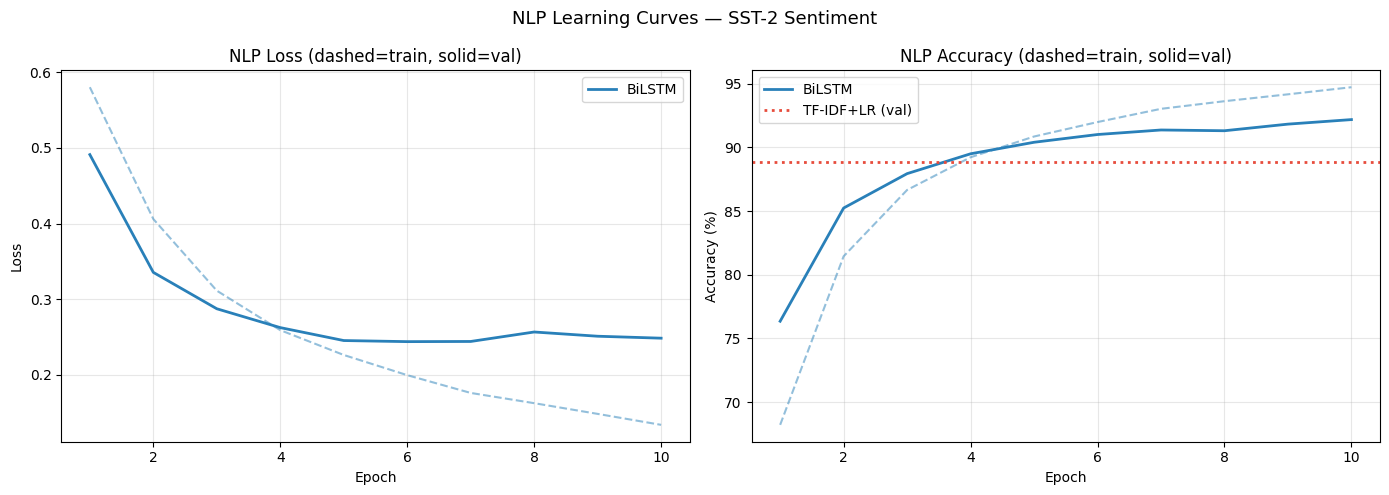

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

nlp_colors = {
    "TF-IDF+LR": "#e74c3c",
    "BiLSTM": "#2980b9",
    "DistilBERT": "#27ae60"
}

for name, h in nlp_histories.items():
    if not h.get("has_curves", False):
        continue

    color = nlp_colors.get(name, "black")
    epochs = range(1, len(h["train_loss"]) + 1)

    # Loss
    axes[0].plot(epochs, h["train_loss"], "--", color=color, alpha=0.5)
    axes[0].plot(epochs, h["val_loss"], "-", color=color, label=name, linewidth=2)

    # Accuracy
    axes[1].plot(epochs, [a * 100 for a in h["train_acc"]], "--", color=color, alpha=0.5)
    axes[1].plot(epochs, [a * 100 for a in h["val_acc"]], "-", color=color, label=name, linewidth=2)


# Optional baseline horizontal line (guarded)
if "TF-IDF+LR" in nlp_histories and "best_val_acc" in nlp_histories["TF-IDF+LR"]:
    axes[1].axhline(
        y=100 * nlp_histories["TF-IDF+LR"]["best_val_acc"],
        color=nlp_colors.get("TF-IDF+LR", "black"),
        linestyle=":",
        linewidth=2,
        label="TF-IDF+LR (val)"
    )


# Formatting
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("NLP Loss (dashed=train, solid=val)")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy (%)")
axes[1].set_title("NLP Accuracy (dashed=train, solid=val)")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle("NLP Learning Curves — SST-2 Sentiment", fontsize=13)
plt.tight_layout()
plt.savefig("outputs/plots/nlp_learning_curves.png", dpi=150)
plt.show()

## 5 — Test Set Evaluation


In [18]:
NLP_CLASS_NAMES = ["negative", "positive"]
nlp_test_results = {}

# TF-IDF+LR
lr_preds = tfidf_lr.predict(nlp_test_texts)
lr_probs = tfidf_lr.predict_proba(nlp_test_texts)

lr_acc = accuracy_score(nlp_test_labels, lr_preds)
lr_prec, lr_rec, lr_f1, _ = precision_recall_fscore_support(
    nlp_test_labels, lr_preds, average="macro"
)
lr_auroc = roc_auc_score(nlp_test_labels, lr_probs[:, 1])

nlp_test_results["TF-IDF+LR"] = {
    "accuracy": lr_acc,
    "precision_macro": lr_prec,
    "recall_macro": lr_rec,
    "f1_macro": lr_f1,
    "auroc_macro": lr_auroc,
    "labels": np.array(nlp_test_labels),
    "preds": lr_preds,
    "probs": lr_probs
}

print(f"TF-IDF+LR — Acc: {100*lr_acc:.2f}% | "
      f"F1: {100*lr_f1:.2f}% | AUROC: {lr_auroc:.4f}")
print(classification_report(nlp_test_labels, lr_preds,
                            target_names=NLP_CLASS_NAMES, digits=3))


# BiLSTM
bilstm.eval()
all_l, all_p, all_pr = [], [], []

with torch.no_grad():
    for X_b, y_b in lstm_test_loader:
        X_b = X_b.to(device)
        logits = bilstm(X_b)
        probs = F.softmax(logits, dim=1)
        _, preds = logits.max(1)

        all_l.extend(y_b.cpu().numpy())
        all_p.extend(preds.cpu().numpy())
        all_pr.extend(probs.cpu().numpy())

al, ap, apr = np.array(all_l), np.array(all_p), np.array(all_pr)

la = accuracy_score(al, ap)
lp, lr2, lf, _ = precision_recall_fscore_support(al, ap, average="macro")
lau = roc_auc_score(al, apr[:, 1])

nlp_test_results["BiLSTM"] = {
    "accuracy": la,
    "precision_macro": lp,
    "recall_macro": lr2,
    "f1_macro": lf,
    "auroc_macro": lau,
    "labels": al,
    "preds": ap,
    "probs": apr
}

print(f"BiLSTM — Acc: {100*la:.2f}% | "
      f"F1: {100*lf:.2f}% | AUROC: {lau:.4f}")
print(classification_report(al, ap,
                            target_names=NLP_CLASS_NAMES, digits=3))


# DistilBERT
distilbert_model.eval()
all_l, all_p, all_pr = [], [], []

with torch.no_grad():
    for batch in bert_test_loader:
        iids = batch["input_ids"].to(device)
        amask = batch["attention_mask"].to(device)

        out = distilbert_model(input_ids=iids, attention_mask=amask)
        probs = F.softmax(out.logits, dim=1)
        preds = out.logits.argmax(dim=1)

        all_l.extend(batch["labels"].cpu().numpy())
        all_p.extend(preds.cpu().numpy())
        all_pr.extend(probs.cpu().numpy())

al, ap, apr = np.array(all_l), np.array(all_p), np.array(all_pr)

ba = accuracy_score(al, ap)
bp, br, bf, _ = precision_recall_fscore_support(al, ap, average="macro")
bau = roc_auc_score(al, apr[:, 1])

nlp_test_results["DistilBERT"] = {
    "accuracy": ba,
    "precision_macro": bp,
    "recall_macro": br,
    "f1_macro": bf,
    "auroc_macro": bau,
    "labels": al,
    "preds": ap,
    "probs": apr
}

print(f"DistilBERT — Acc: {100*ba:.2f}% | "
      f"F1: {100*bf:.2f}% | AUROC: {bau:.4f}")
print(classification_report(al, ap,
                            target_names=NLP_CLASS_NAMES, digits=3))

TF-IDF+LR — Acc: 81.77% | F1: 81.69% | AUROC: 0.9052
              precision    recall  f1-score   support

    negative      0.848     0.766     0.805       428
    positive      0.794     0.867     0.829       444

    accuracy                          0.818       872
   macro avg      0.821     0.817     0.817       872
weighted avg      0.820     0.818     0.817       872

BiLSTM — Acc: 83.60% | F1: 83.60% | AUROC: 0.9036
              precision    recall  f1-score   support

    negative      0.813     0.864     0.838       428
    positive      0.861     0.809     0.834       444

    accuracy                          0.836       872
   macro avg      0.837     0.837     0.836       872
weighted avg      0.837     0.836     0.836       872

DistilBERT — Acc: 89.22% | F1: 89.20% | AUROC: 0.9679
              precision    recall  f1-score   support

    negative      0.907     0.869     0.888       428
    positive      0.879     0.914     0.896       444

    accuracy             

## 6 — Confusion Matrices


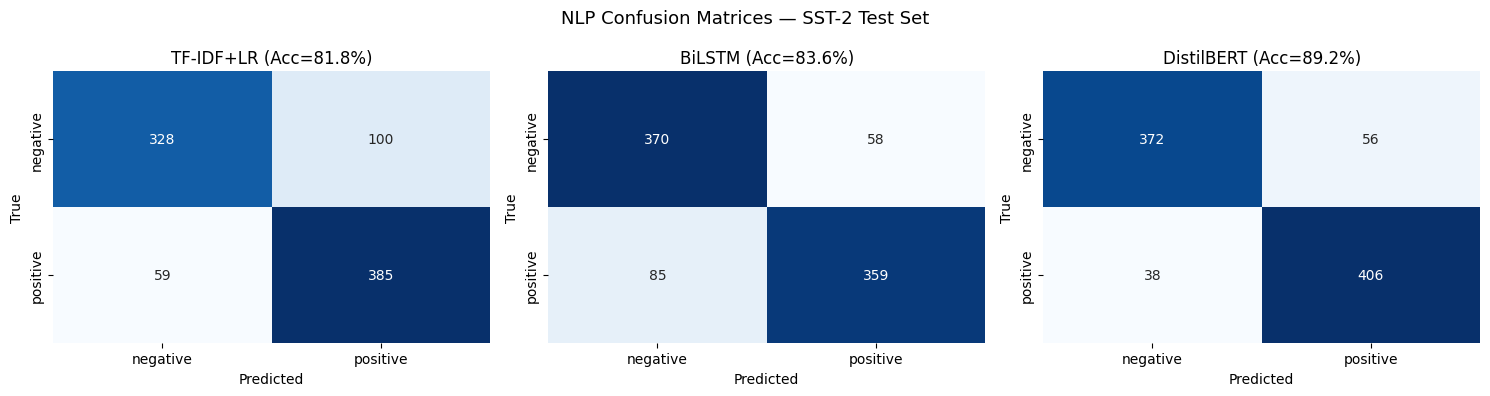

In [19]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Ensure output directory exists
os.makedirs("outputs/plots", exist_ok=True)

# Choose up to 3 models safely
items = list(nlp_test_results.items())[:3]
n = len(items)

fig, axes = plt.subplots(1, n, figsize=(5 * n, 4))
if n == 1:
    axes = [axes]  # make iterable

for idx, (name, res) in enumerate(items):
    cm = confusion_matrix(res["labels"], res["preds"])

    ax = axes[idx]
    im = ax.imshow(cm)  # no explicit colors set

    # annotate cells
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center")

    ax.set_xticks(range(len(NLP_CLASS_NAMES)))
    ax.set_yticks(range(len(NLP_CLASS_NAMES)))
    ax.set_xticklabels(NLP_CLASS_NAMES)
    ax.set_yticklabels(NLP_CLASS_NAMES)

    ax.set_title(f"{name} (Acc={100*res['accuracy']:.1f}%)")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

plt.suptitle("NLP Confusion Matrices — SST-2 Test Set", fontsize=13)
plt.tight_layout()
plt.savefig("outputs/plots/nlp_confusion_matrices.png", dpi=150)
plt.show()

## 7 — Adversarial Attacks

Manual adversarial perturbations for reliability and speed:
- **Synonym Swap**: Replace words with WordNet synonyms
- **Char Perturbation**: Randomly swap/insert/delete characters

200 test samples per model per attack.


In [26]:
import nltk
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)
from nltk.corpus import wordnet

def get_synonyms(word):
    synonyms = set()
    for syn in wordnet.synsets(word):
        for lemma in syn.lemmas():
            if lemma.name().lower() != word.lower() and "_" not in lemma.name():
                synonyms.add(lemma.name().lower())
    return list(synonyms)

def synonym_attack(text, n_attempts=15):
    words = text.split()
    if len(words) < 2:
        return text
    tried = set()
    for _ in range(n_attempts):
        idx = random.randint(0, len(words) - 1)
        if idx in tried:
            continue
        tried.add(idx)
        syns = get_synonyms(words[idx])
        if syns:
            new_words = words.copy()
            new_words[idx] = random.choice(syns)
            return " ".join(new_words)
    return text

def char_perturb(text, n_words=3):
    words = text.split()
    if len(words) < 2:
        return text
    indices = random.sample(range(len(words)), min(n_words, len(words)))
    for i in indices:
        w = words[i]
        if len(w) > 2:
            op = random.choice(["swap", "delete", "insert"])
            pos = random.randint(0, len(w) - 2)
            if op == "swap":
                w = list(w)
                w[pos], w[pos+1] = w[pos+1], w[pos]
                w = "".join(w)
            elif op == "delete":
                w = w[:pos] + w[pos+1:]
            else:
                w = w[:pos] + random.choice("abcdefghijklmnopqrstuvwxyz") + w[pos:]
            words[i] = w
    return " ".join(words)

def predict_lr_fn(texts):
    return tfidf_lr.predict_proba(texts)

def predict_lstm_fn(texts):
    bilstm.eval()
    X = torch.tensor([text_to_indices(t) for t in texts], dtype=torch.long).to(device)
    with torch.no_grad():
        return F.softmax(bilstm(X), dim=1).cpu().numpy()

def predict_bert_fn(texts):
    distilbert_model.eval()
    all_probs = []
    for i in range(0, len(texts), 16):
        bt = texts[i:i+16]
        enc = distilbert_tokenizer(
            bt,
            truncation=True,
            padding="max_length",
            max_length=128,
            return_tensors="pt"
        )
        with torch.no_grad():
            out = distilbert_model(
                input_ids=enc["input_ids"].to(device),
                attention_mask=enc["attention_mask"].to(device)
            )
            all_probs.append(F.softmax(out.logits, dim=1).cpu().numpy())
    return np.vstack(all_probs)

NLP_ATK_N = 200
pred_fns = {
    "TF-IDF+LR": predict_lr_fn,
    "BiLSTM": predict_lstm_fn,
    "DistilBERT": predict_bert_fn
}
atk_fns = {
    "SynonymSwap": synonym_attack,
    "CharPerturb": char_perturb
}

sample_idx = random.sample(range(len(nlp_test_texts)), NLP_ATK_N)
sample_texts = [nlp_test_texts[i] for i in sample_idx]
sample_labels = [nlp_test_labels[i] for i in sample_idx]

nlp_adv_results = {}
for model_name, pred_fn in pred_fns.items():
    nlp_adv_results[model_name] = {}

    print("\n" + "=" * 60)
    print(f"Attacking: {model_name}")
    print("=" * 60)

    clean_probs = pred_fn(sample_texts)
    clean_preds = clean_probs.argmax(axis=1)
    clean_confs = clean_probs.max(axis=1)
    clean_acc = (clean_preds == np.array(sample_labels)).mean()

    for atk_name, atk_fn in atk_fns.items():
        t0 = time.time()

        adv_texts = [atk_fn(t) for t in sample_texts]
        adv_probs = pred_fn(adv_texts)
        adv_preds = adv_probs.argmax(axis=1)
        adv_confs = adv_probs.max(axis=1)

        adv_acc = (adv_preds == np.array(sample_labels)).mean()
        asr = (clean_preds != adv_preds).mean()
        conf_drop = float(clean_confs.mean() - adv_confs.mean())

        class_asr = []
        labels_np = np.array(sample_labels)
        for c in range(2):
            mask = labels_np == c
            if mask.sum() > 0:
                class_asr.append(((clean_preds != adv_preds) & mask).sum() / mask.sum())
            else:
                class_asr.append(0.0)

        worst_class_asr = max(class_asr)
        accuracy_drop = clean_acc - adv_acc
        risk_score, gate = compute_risk_score(accuracy_drop, conf_drop, asr, worst_class_asr)
        elapsed = time.time() - t0

        nlp_adv_results[model_name][atk_name] = {
            "clean_acc": clean_acc,
            "adv_acc": adv_acc,
            "accuracy_drop": accuracy_drop,
            "asr": asr,
            "confidence_drop": conf_drop,
            "worst_class_asr": worst_class_asr,
            "risk_score": risk_score,
            "gate": gate,
            "attack_time_s": elapsed
        }

        print(
            f"  {atk_name}: Adv Acc={100*adv_acc:.1f}% | "
            f"ASR={100*asr:.1f}% | ConfDrop={conf_drop:.3f} | "
            f"WorstClassASR={100*worst_class_asr:.1f}% | "
            f"Risk={risk_score:.4f} [{gate}] | {elapsed:.1f}s"
        )


Attacking: TF-IDF+LR
  SynonymSwap: Adv Acc=81.5% | ASR=6.5% | ConfDrop=0.011 | WorstClassASR=11.8% | Risk=0.0350 [PASS] | 3.2s
  CharPerturb: Adv Acc=78.0% | ASR=7.0% | ConfDrop=0.022 | WorstClassASR=9.7% | Risk=0.0481 [PASS] | 0.0s

Attacking: BiLSTM
  SynonymSwap: Adv Acc=77.5% | ASR=6.0% | ConfDrop=-0.000 | WorstClassASR=8.4% | Risk=0.0416 [PASS] | 0.1s
  CharPerturb: Adv Acc=72.5% | ASR=10.0% | ConfDrop=0.014 | WorstClassASR=14.0% | Risk=0.0811 [PASS] | 0.0s

Attacking: DistilBERT
  SynonymSwap: Adv Acc=85.0% | ASR=3.5% | ConfDrop=0.001 | WorstClassASR=4.3% | Risk=0.0241 [PASS] | 0.9s
  CharPerturb: Adv Acc=84.5% | ASR=8.0% | ConfDrop=0.017 | WorstClassASR=9.3% | Risk=0.0487 [PASS] | 0.8s


## 8 — Inference Benchmarks


In [27]:
nlp_inf_results = {}

# ---------------------------
# TF-IDF+LR (CPU)
# ---------------------------
lats = []
for i in range(min(500, len(nlp_test_texts))):
    t0 = time.perf_counter()
    _ = tfidf_lr.predict_proba([nlp_test_texts[i]])
    lats.append((time.perf_counter() - t0) * 1000)

ts = time.time()
_ = tfidf_lr.predict_proba(nlp_test_texts)
lr_tp = len(nlp_test_texts) / (time.time() - ts)

nlp_inf_results["TF-IDF+LR"] = {
    "p50_ms": float(np.percentile(lats, 50)),
    "p90_ms": float(np.percentile(lats, 90)),
    "throughput_sps": float(lr_tp),
    "inf_vram_mb": 0.0
}

print(
    f"TF-IDF+LR: p50={nlp_inf_results['TF-IDF+LR']['p50_ms']:.2f}ms | "
    f"p90={nlp_inf_results['TF-IDF+LR']['p90_ms']:.2f}ms | "
    f"throughput={lr_tp:.0f} samp/s"
)


# ---------------------------
# BiLSTM (PyTorch)
# ---------------------------
bilstm.eval()
lats = []

sl = DataLoader(lstm_test_ds, batch_size=1, shuffle=False)
cnt = 0

for X_b, _ in sl:
    X_b = X_b.to(device)

    if device.type == "cuda":
        torch.cuda.synchronize()

    t0 = time.perf_counter()
    with torch.no_grad():
        _ = bilstm(X_b)

    if device.type == "cuda":
        torch.cuda.synchronize()

    lats.append((time.perf_counter() - t0) * 1000)
    cnt += 1
    if cnt >= 500:
        break

if device.type == "cuda":
    torch.cuda.reset_peak_memory_stats()
    torch.cuda.synchronize()

tn = 0
ts = time.time()

with torch.no_grad():
    for X_b, _ in lstm_test_loader:
        X_b = X_b.to(device)
        _ = bilstm(X_b)
        tn += X_b.size(0)

if device.type == "cuda":
    torch.cuda.synchronize()

lt = tn / (time.time() - ts)
lv = torch.cuda.max_memory_allocated() / 1024**2 if device.type == "cuda" else 0.0

nlp_inf_results["BiLSTM"] = {
    "p50_ms": float(np.percentile(lats, 50)),
    "p90_ms": float(np.percentile(lats, 90)),
    "throughput_sps": float(lt),
    "inf_vram_mb": float(lv)
}

print(
    f"BiLSTM: p50={nlp_inf_results['BiLSTM']['p50_ms']:.2f}ms | "
    f"p90={nlp_inf_results['BiLSTM']['p90_ms']:.2f}ms | "
    f"throughput={lt:.0f} samp/s | VRAM={lv:.0f}MB"
)


# ---------------------------
# DistilBERT (PyTorch)
# ---------------------------
distilbert_model.eval()
lats = []

sl = DataLoader(bert_test_ds, batch_size=1, shuffle=False)
cnt = 0

for batch in sl:
    iids = batch["input_ids"].to(device)
    amask = batch["attention_mask"].to(device)

    if device.type == "cuda":
        torch.cuda.synchronize()

    t0 = time.perf_counter()
    with torch.no_grad():
        _ = distilbert_model(input_ids=iids, attention_mask=amask)

    if device.type == "cuda":
        torch.cuda.synchronize()

    lats.append((time.perf_counter() - t0) * 1000)
    cnt += 1
    if cnt >= 500:
        break

if device.type == "cuda":
    torch.cuda.reset_peak_memory_stats()
    torch.cuda.synchronize()

tn = 0
ts = time.time()

with torch.no_grad():
    for batch in bert_test_loader:
        iids = batch["input_ids"].to(device)
        amask = batch["attention_mask"].to(device)
        _ = distilbert_model(input_ids=iids, attention_mask=amask)
        tn += iids.size(0)

if device.type == "cuda":
    torch.cuda.synchronize()

bt = tn / (time.time() - ts)
bv = torch.cuda.max_memory_allocated() / 1024**2 if device.type == "cuda" else 0.0

nlp_inf_results["DistilBERT"] = {
    "p50_ms": float(np.percentile(lats, 50)),
    "p90_ms": float(np.percentile(lats, 90)),
    "throughput_sps": float(bt),
    "inf_vram_mb": float(bv)
}

print(
    f"DistilBERT: p50={nlp_inf_results['DistilBERT']['p50_ms']:.2f}ms | "
    f"p90={nlp_inf_results['DistilBERT']['p90_ms']:.2f}ms | "
    f"throughput={bt:.0f} samp/s | VRAM={bv:.0f}MB"
)

TF-IDF+LR: p50=0.81ms | p90=0.89ms | throughput=32839 samp/s
BiLSTM: p50=1.21ms | p90=2.14ms | throughput=25430 samp/s | VRAM=1263MB
DistilBERT: p50=5.00ms | p90=5.73ms | throughput=279 samp/s | VRAM=1241MB


## 9 — Full NLP Summary


In [29]:
# Summary table
import math

def _find_key(d, desired):
    """
    Try to find the best key match for 'desired' inside dict 'd'.
    1) exact match
    2) case-insensitive match
    3) remove non-alnum and match
    Returns: matched_key or None
    """
    if d is None:
        return None
    if desired in d:
        return desired

    # case-insensitive exact
    low_map = {str(k).lower(): k for k in d.keys()}
    if desired.lower() in low_map:
        return low_map[desired.lower()]

    # normalized match (remove non-alphanumeric)
    def norm(s):
        return "".join(ch for ch in str(s).lower() if ch.isalnum())

    desired_n = norm(desired)
    norm_map = {norm(k): k for k in d.keys()}
    return norm_map.get(desired_n, None)

def _safe_get(d, desired_key, default=None):
    k = _find_key(d, desired_key)
    return d[k] if k is not None else default

def _fmt_num(x, fmt):
    try:
        if x is None:
            return "N/A"
        if isinstance(x, str):
            return x
        if isinstance(x, (float, int)) and (isinstance(x, float) and math.isnan(x)):
            return "N/A"
        return format(float(x), fmt)
    except Exception:
        return "N/A"

rows = []
wanted_models = ["TF-IDF+LR", "BiLSTM", "DistilBERT"]

missing_report = []

for desired_name in wanted_models:
    h = _safe_get(nlp_histories, desired_name, default=None)
    t = _safe_get(nlp_test_results, desired_name, default=None)
    m = _safe_get(nlp_model_meta, desired_name, default=None)
    inf = _safe_get(nlp_inf_results, desired_name, default=None)
    adv = _safe_get(nlp_adv_results, desired_name, default=None)

    # Track missing components (so you know what dictionary is the issue)
    miss = []
    if h is None: miss.append("nlp_histories")
    if t is None: miss.append("nlp_test_results")
    if m is None: miss.append("nlp_model_meta")
    if inf is None: miss.append("nlp_inf_results")
    if adv is None: miss.append("nlp_adv_results")

    if miss:
        missing_report.append((desired_name, miss))

    # If test results are missing, we can’t build a meaningful comparison row → skip
    if t is None:
        continue

    # Worst attack by risk score (guarded)
    if isinstance(adv, dict) and len(adv) > 0:
        worst_atk = max(adv.items(), key=lambda x: x[1].get("risk_score", float("-inf")))
        worst_asr = worst_atk[1].get("asr", float("nan"))
        worst_risk = worst_atk[1].get("risk_score", float("nan"))
        worst_gate = worst_atk[1].get("gate", "N/A")
    else:
        worst_asr = float("nan")
        worst_risk = float("nan")
        worst_gate = "N/A"

    # Params formatting (guarded)
    params_val = m.get("params") if isinstance(m, dict) else "N/A"
    if isinstance(params_val, int):
        pstr = f"{params_val:,}"
    else:
        pstr = str(params_val) if params_val is not None else "N/A"

    # History metrics (guarded)
    ckpt_mb = h.get("ckpt_size_mb") if isinstance(h, dict) else None
    total_time = h.get("total_time") if isinstance(h, dict) else None
    peak_vram = h.get("peak_vram_mb") if isinstance(h, dict) else None
    best_val = h.get("best_val_acc") if isinstance(h, dict) else None

    # Inference metrics (guarded)
    p50 = inf.get("p50_ms") if isinstance(inf, dict) else None
    p90 = inf.get("p90_ms") if isinstance(inf, dict) else None
    thr = inf.get("throughput_sps") if isinstance(inf, dict) else None

    rows.append({
        "Model": desired_name,
        "Params": pstr,
        "Ckpt (MB)": _fmt_num(ckpt_mb, ".1f"),
        "Train Time": (f"{float(total_time):.0f}s" if total_time is not None else "N/A"),
        "Peak VRAM (MB)": _fmt_num(peak_vram, ".0f"),
        "Val Acc (%)": (f"{100*float(best_val):.2f}" if best_val is not None else "N/A"),
        "Test Acc (%)": f"{100*float(t.get('accuracy', float('nan'))):.2f}",
        "F1 Macro (%)": f"{100*float(t.get('f1_macro', float('nan'))):.2f}",
        "AUROC": f"{float(t.get('auroc_macro', float('nan'))):.4f}",
        "Worst ASR (%)": (f"{100*float(worst_asr):.1f}" if worst_asr == worst_asr else "N/A"),
        "Worst Risk": (f"{float(worst_risk):.4f}" if worst_risk == worst_risk else "N/A"),
        "Gate": worst_gate,
        "p50 (ms)": _fmt_num(p50, ".2f"),
        "p90 (ms)": _fmt_num(p90, ".2f"),
        "Throughput": (f"{float(thr):.0f}" if thr is not None else "N/A"),
    })

summary_df = pd.DataFrame(rows)

# Save CSV
summary_df.to_csv("outputs/nlp_model_comparison.csv", index=False)

# Print helpful debug info once
if missing_report:
    print("\n[WARN] Some components were missing for certain models (showing which dict lacked the key):")
    for model, miss in missing_report:
        print(f"  - {model}: missing in {', '.join(miss)}")

    # Also show what keys exist (super helpful to fix naming)
    print("\n[DEBUG] Available keys:")
    print("  nlp_histories:", sorted(list(nlp_histories.keys())) if isinstance(nlp_histories, dict) else "N/A")
    print("  nlp_test_results:", sorted(list(nlp_test_results.keys())) if isinstance(nlp_test_results, dict) else "N/A")
    print("  nlp_model_meta:", sorted(list(nlp_model_meta.keys())) if isinstance(nlp_model_meta, dict) else "N/A")
    print("  nlp_inf_results:", sorted(list(nlp_inf_results.keys())) if isinstance(nlp_inf_results, dict) else "N/A")
    print("  nlp_adv_results:", sorted(list(nlp_adv_results.keys())) if isinstance(nlp_adv_results, dict) else "N/A")

print("\n" + "=" * 80)
print("NLP MODEL COMPARISON 2")
print("=" * 80)
print(summary_df.to_string(index=False))


[WARN] Some components were missing for certain models (showing which dict lacked the key):
  - DistilBERT: missing in nlp_histories

[DEBUG] Available keys:
  nlp_histories: ['BiLSTM', 'TF-IDF+LR']
  nlp_test_results: ['BiLSTM', 'DistilBERT', 'TF-IDF+LR']
  nlp_model_meta: ['BiLSTM', 'DistilBERT', 'TF-IDF+LR']
  nlp_inf_results: ['BiLSTM', 'DistilBERT', 'TF-IDF+LR']
  nlp_adv_results: ['BiLSTM', 'DistilBERT', 'TF-IDF+LR']

NLP MODEL COMPARISON 2
     Model     Params Ckpt (MB) Train Time Peak VRAM (MB) Val Acc (%) Test Acc (%) F1 Macro (%)  AUROC Worst ASR (%) Worst Risk Gate p50 (ms) p90 (ms) Throughput
 TF-IDF+LR     20,001       0.9         6s              0       88.83        81.77        81.69 0.9052           7.0     0.0481 PASS     0.81     0.89      32839
    BiLSTM  2,236,034       8.5        93s           1578       92.19        83.60        83.60 0.9036          10.0     0.0811 PASS     1.21     2.14      25430
DistilBERT 66,955,010       N/A        N/A            N/A     

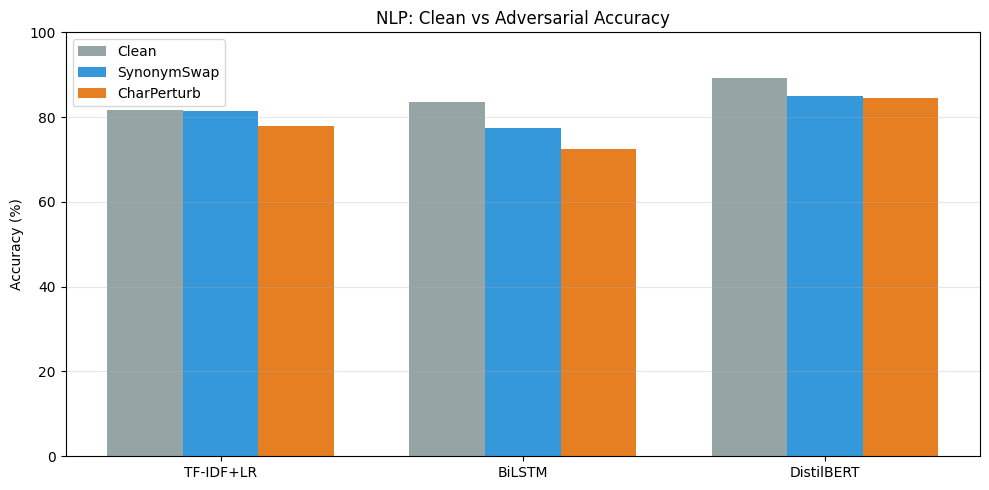

In [31]:
import numpy as np
import matplotlib.pyplot as plt

models = ["TF-IDF+LR", "BiLSTM", "DistilBERT"]
clean_accs = [81.77, 83.60, 89.22]
synonym = [81.5, 77.5, 85.0]
charpert = [78.0, 72.5, 84.5]

x = np.arange(len(models))
w = 0.25

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - w, clean_accs, w, label="Clean", color="#95a5a6")
ax.bar(x, synonym, w, label="SynonymSwap", color="#3498db")
ax.bar(x + w, charpert, w, label="CharPerturb", color="#e67e22")

ax.set_ylabel("Accuracy (%)")
ax.set_title("NLP: Clean vs Adversarial Accuracy")
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()
ax.grid(alpha=0.3, axis="y")
ax.set_ylim(0, 100)
plt.tight_layout()
plt.savefig("outputs/plots/nlp_adversarial_comparison.png", dpi=150)
plt.show()

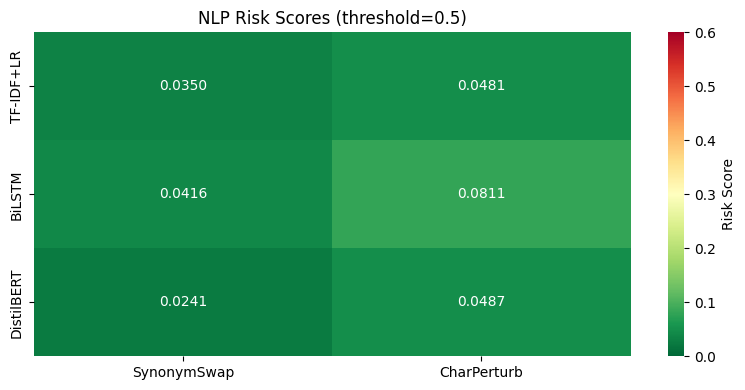

In [32]:
import seaborn as sns

models = ["TF-IDF+LR", "BiLSTM", "DistilBERT"]
attacks = ["SynonymSwap", "CharPerturb"]
risk_matrix = np.array([
    [0.0350, 0.0481],
    [0.0416, 0.0811],
    [0.0241, 0.0487]
])

fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(risk_matrix, annot=True, fmt=".4f", cmap="RdYlGn_r",
            xticklabels=attacks, yticklabels=models,
            vmin=0, vmax=0.6, ax=ax, cbar_kws={"label": "Risk Score"})
ax.set_title("NLP Risk Scores (threshold=0.5)")
plt.tight_layout()
plt.savefig("outputs/plots/nlp_risk_heatmap.png", dpi=150)
plt.show()